<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# TS4: Primeras nociones de estimación espectral
#### Sofía Makkos

#### Introducción
En el presente trabajo se observarán los efectos de dos aplicaciones. En primer lugar, el ventaneo, el cual se utiliza en todas las señales sin realmente darnos cuenta. Cuando se selecciona una porción de una señal para analizarla, se realiza un truncamiento de la señal extendida. A la vez, se aprovechan los efectos del ventaneo intencionalmente para filtrar. Por lo tanto, conseguimos una señal de longitud finita $\widehat{x}[n]$ a partir de la señal original infinita $x[n]$ y una ventana (implícita o no) $w_N[n]$:
\begin{equation}
\widehat{x}[n]=x[n]w_N[n]
\end{equation}
Por otro lado, los estimadores. Estos se emplean, justamente, para estimar medidas deseadas basadas en un número finito de realizaciones. A estas herramientas se les calcularán la varianza, sobre la fluctuación del valor del estimador, y el sesgo, la diferencia entre el valor esperado del estimador y el valor "real". 

Se utilizarán dos estimadores. La estimación de la amplitud $\widehat{a}_1^i$ de las distintas realizaciones se hará en base al módulo de la FFT de la multiplicación entre la señal original y cada ventana aplicada.
\begin{equation}
\widehat{a}_1^i=|X_w^i(\ohm_0)|=|F\{x(n)w_i(n)\}|
\end{equation}
El estimador de frecuencia $\ohm_1$ buscará el valor máximo de cada realización.
\begin{equation}
\widehat{\ohm}_1^i=argmax\{|X_w^i(\ohm)|\}
\end{equation}

#### Desarrollo (3dB)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as win 
import pandas as pd

N=1000
fs=1000

def mi_fft(x, fs=fs):
    x_fft = np.fft.fft(x, axis=1)
    x_fft = x_fft[:,:N//2]
    freq = np.fft.fftfreq(N, 1/fs)[:N//2]
    x_fft_abs = np.abs(x_fft)
    
    return freq, x_fft_abs

Inicializo las variables y funciones, contemplando sus dimensiones, siendo que se realizarán 200 (tamaño de *f_r*) realizaciones con 1000 muestras (*N*) cada una. En este caso, se utilizará un SNR de 3dB. Este último modificará la escala del ruido implementado en la sinusoidal.

In [2]:
omega_cero = np.pi/2
f_r = np.random.uniform(-2,2,size=200)

omega_uno = omega_cero + f_r * 2 * np.pi/N
nn = np.arange(0,N,1)
s = np.sqrt(2)*np.sin(np.outer(omega_uno,nn))
Ps = np.var(s)
SNR = 3
sigma = np.sqrt(Ps/np.power(10,SNR/10)) 
n_a = np.random.normal(scale=sigma,size=s.shape)

x = s + n_a

#### Ventana rectangular (3dB)

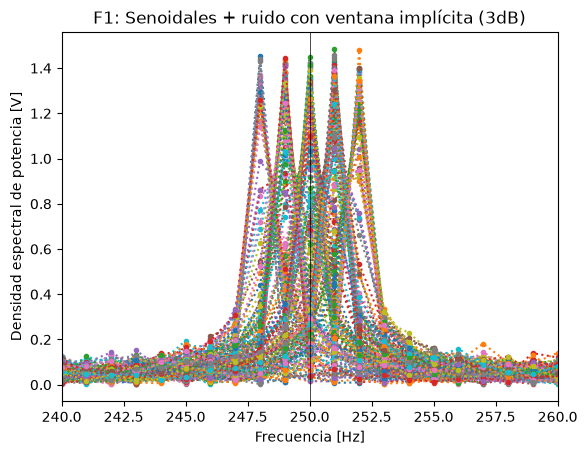

In [3]:
freq, x_fft_abs = mi_fft(x)
x_fft_abs = 2*x_fft_abs/N
x_fft_abs_traspuesta = np.transpose(x_fft_abs)

plt.figure(1)
plt.plot(freq,x_fft_abs_traspuesta,":.")
plt.xlim(240,260)
plt.title("F1: Senoidales + ruido con ventana implícita (3dB)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [V]")
plt.axvline(x=250, ymin=0, ymax=1.5, color="black", linewidth=0.5)

Debido a la gran cantidad de realizaciones y la distribución de los posibles valores de *f_r*, se aprecia esta disperción, con ciertos picos cercanos a un valor conocido $\approx\sqrt2$. 
Por otro lado, como tal indica en el título de la Figura 1, en esta señal se encuentra la ventana implícita, generada debido a las *N* muestras utilizadas. Así, conseguimos una ventana rectangular, la cual, al aplicarle la Transformada de Fourier, tenemos la función Kernel Dirichlet:
\begin{equation}
W_N(w)=\frac{sin(wN/2)}{sin(w/2)}=N\frac{sinc(wN/2)}{sinc(w/2)}
\end{equation}


A continuación, definimos nuestros estimadores

In [4]:
a_1_rect = x_fft_abs[:,freq==(omega_cero/(2*np.pi))*N]
indice_maximo = np.argmax(x_fft_abs, axis=1)
omega_rect = freq[indice_maximo]*2*np.pi/fs

#### Ventana Flattop (3dB)

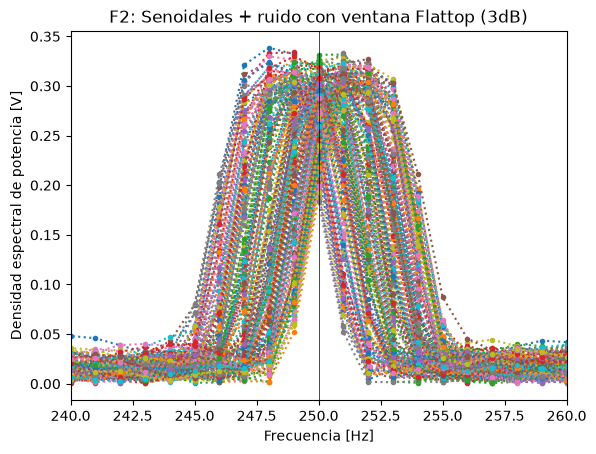

In [5]:
flat=win.flattop(N)
x_flat=flat*x

freq, x_fft_abs = mi_fft(x_flat)
x_fft_abs = 2*x_fft_abs/N
x_fft_abs_traspuesta = np.transpose(x_fft_abs)
plt.figure(2)
plt.plot(freq,x_fft_abs_traspuesta,":.")
plt.xlim(240,260)
plt.title("F2: Senoidales + ruido con ventana Flattop (3dB)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [V]")
plt.axvline(x=250, ymin=0, ymax=1.5, color="black", linewidth=0.5)

Al aplicarle esta nueva ventana a nuestra sinusoidal ruidosa mediante *win.flattop*, conseguimos una FFT bastante distinta a la anterior. En la Figura 2 se puede apreciar un "puente", una zona inferior que evita los valores nulos, produciendo que la distribución de la densidad espectral de potencia se vea concentrada, con la zona superior más aplanada y sin picos aparentes.

In [6]:
a_1_flat = x_fft_abs[:,freq==(omega_cero/(2*np.pi))*N]
indice_maximo = np.argmax(x_fft_abs, axis=1)
omega_flat = freq[indice_maximo]*2*np.pi/fs

#### Ventana Blackmanharris (3dB)

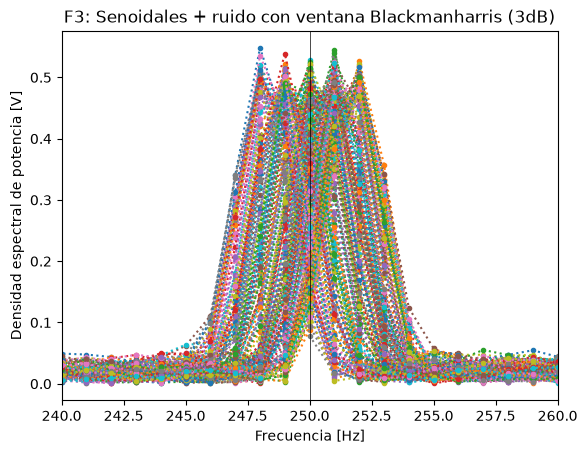

In [7]:
blackh=win.blackmanharris(N)
x_blackh=x*blackh

freq, x_fft_abs = mi_fft(x_blackh)
x_fft_abs_norm = 2*x_fft_abs/N
x_fft_abs_traspuesta = np.transpose(x_fft_abs_norm)
plt.figure(3)
plt.plot(freq,x_fft_abs_traspuesta,":.")
plt.xlim(240,260)
plt.title("F3: Senoidales + ruido con ventana Blackmanharris (3dB)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [V]")
plt.axvline(x=250, ymin=0, ymax=1.5, color="black", linewidth=0.5)

En la Figura 3, se podría considerar que se ve un punto intermedio entre la ventana rectangular y la flattop, ya que se distinguen picos al igual que en la Figura 1 y se ve cierto "puente" alrededor del valor central de la señal. Además, nuevamente la amplitud máxima de la densidad espectral de potencia se vio modificada.

In [8]:
a_1_blackh = x_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*N]
indice_maximo = np.argmax(x_fft_abs_norm, axis=1)
omega_blackh = freq[indice_maximo]*2*np.pi/fs

#### Ventana a elección: Hann (3dB)

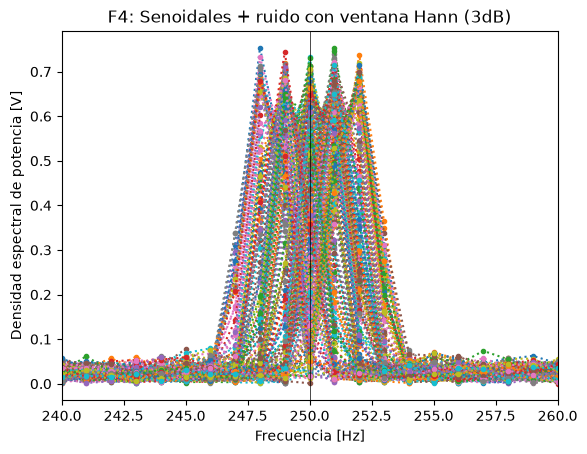

In [9]:
hann=win.hann(N)
x_hann=x*hann

freq, x_fft_abs = mi_fft(x_hann)
x_fft_abs_norm = 2*x_fft_abs/N
x_fft_abs_traspuesta = np.transpose(x_fft_abs_norm)
plt.figure(4)
plt.plot(freq,x_fft_abs_traspuesta,":.")
plt.xlim(240,260)
plt.title("F4: Senoidales + ruido con ventana Hann (3dB)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [V]")
plt.axvline(x=250, ymin=0, ymax=1.5, color="black", linewidth=0.5)

Al igual que con las demás ventanas, se empleó la librería de scipy.signal.windows, para elegir así la ventana Hann. En esta, se aprecia que los picos superiores son más pronunciados que en la Figura 3, y a la vez, que apenas se puede distinguir un intento de "puente" en la zona inferior central.

Consecuentemente, se puede decir que conseguimos una transición progresiva de ventana a ventana en cuanto a la manera en que cada una se vio afectada; $Rectangular \longrightarrow Hann \longrightarrow Blackmanharris \longrightarrow Flattop.$

In [10]:
a_1_hann = x_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*N]
indice_maximo = np.argmax(x_fft_abs_norm, axis=1)
omega_hann = freq[indice_maximo]*2*np.pi/fs

#### Histogramas de comparación de estimadores de cada ventana (3dB)

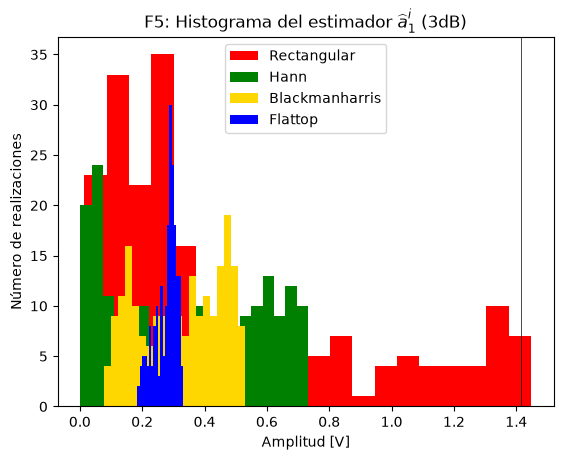

In [11]:
plt.figure(5)
plt.hist(a_1_rect, bins=20, color="red", label="Rectangular")
plt.hist(a_1_hann, bins=20, color="green", label="Hann")
plt.hist(a_1_blackh, bins=20, color="gold", label="Blackmanharris")
plt.hist(a_1_flat, bins=20, color="blue", label="Flattop")
plt.title("F5: Histograma del estimador $\widehat{a}_1^i$ (3dB)")
plt.xlabel("Amplitud [V]")
plt.ylabel("Número de realizaciones")
plt.legend()
plt.axvline(x=np.sqrt(2), ymin=0, ymax=30, color="black", linewidth=0.5)

Ahora, para analizar el estimador de amplitud calculado en cada situación, se ejecutó la Figura 5, de manera que cada señal demuestre ilustrativamente su sesgo y varianza. 

- Ventana rectangular: demuestra una disperción indefinida a lo largo de los posibles valores la amplitud, teniendo una supuesta concentración cercanos a cifras nulas. Sin embargo, a diferencia de las demás, por medio de este estimador, en ciertas realizaciones se consigue el valor esperado de $\sqrt2$. (Sesgo considerable, gran varianza).
- Ventana Hann: en esta situación, aparenta ahora que los valores de la amplitud se encuentran distribuidos desde el 0 hasta aproximadamente la mitad del valor máximo posible, por lo que se podría decir que el máximo se redujo a la mitad. (Sesgo mayor, varianza notable).
- Ventana Blackmanharris: en comparación a la anterior, tenemos una disperción menor y nuevamente lejana a $\sqrt2$. No obstante, aparenta una tendencia más concentrada. (Gran sesgo, poca varianza).
- Ventana Flattop: la distribución de las amplitudes se encuentra realmente concentrada en un rango mucho menor, aunque alejado completamente de $\sqrt2$. (Gran sesgo, varianza discriminable).

Además, un detalle no menor, es cómo el ancho de cada barra decae a medida que disminuye la varianza, demostrando así la gran concentración de los valores.

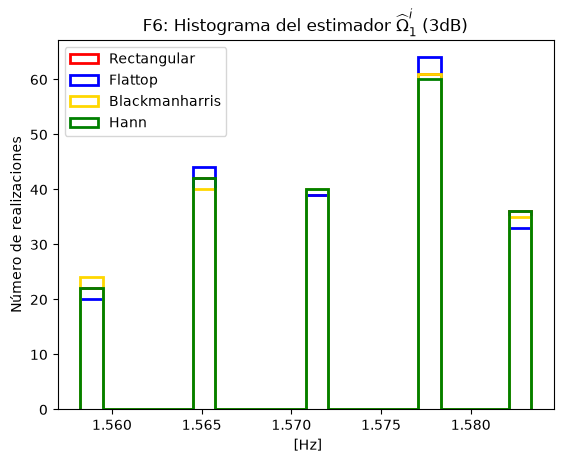

In [12]:
plt.figure(6)
plt.hist(omega_rect, bins=20, color="red", histtype="step", linewidth=2, label="Rectangular")
plt.hist(omega_flat, bins=20, color="blue", histtype="step", linewidth=2, label="Flattop")
plt.hist(omega_blackh, bins=20, color="gold", histtype="step", linewidth=2, label="Blackmanharris")
plt.hist(omega_hann, bins=20, color="green", histtype="step", linewidth=2, label="Hann")
plt.title("F6: Histograma del estimador $\widehat{Ω}_1^i$ (3dB)")
plt.xlabel(" [Hz]")
plt.ylabel("Número de realizaciones")
plt.legend()

En este caso, la distribución de la frecuencia se expresa en cinco picos principales. Debido a la configuración de $\ohm_1$, podemos considerar que las frecuencias se extienden alrededor del centro $\ohm_0=\frac{\pi}{2}$, con dos bins a cada lado, atribuidos a la distribución uniforme del *f_r*. Las cuatro señales ventaneadas evidencian similitud en estos puntos. Además, se podría tener en cuenta la manera en que el punto central parece disponer de la mayor cantidad de realizaciones, y decae hacia los extremos.

A manera de comprobación, también, se pueden observar los números de realizaciones de, por ejemplo, la ventana Hann, y asegurar que se suman 200 realizaciones a estas columnas.

#### Sesgos y Varianzas (3dB)

In [13]:
#Rectangular
esp_a_1 = np.sum(a_1_rect)/200  #Lo mismo que usar np.mean(a_1_rect)
s_a_1_rect=esp_a_1-np.sqrt(2)
var_a_1_rect = np.sum((a_1_rect-esp_a_1)**2)/200

esp_ohm_1 = np.sum(omega_rect)/200 
s_ohm_1_rect=np.mean(esp_ohm_1-omega_uno)
var_ohm_1_rect = np.sum((omega_rect-esp_ohm_1)**2)/200

# Flattop
esp_a_1 = np.sum(a_1_flat)/200  
s_a_1_flat=esp_a_1-np.sqrt(2)
var_a_1_flat = np.sum((a_1_flat-esp_a_1)**2)/200

esp_ohm_1 = np.sum(omega_flat)/200 
s_ohm_1_flat=np.mean(esp_ohm_1-omega_uno)
var_ohm_1_flat = np.sum((omega_flat-esp_ohm_1)**2)/200

#Blackmanharris
esp_a_1 = np.sum(a_1_blackh)/200 
s_a_1_black=esp_a_1-np.sqrt(2)
var_a_1_black = np.sum((a_1_blackh-esp_a_1)**2)/200

esp_ohm_1 = np.sum(omega_blackh)/200 
s_ohm_1_black=np.mean(esp_ohm_1-omega_uno)
var_ohm_1_black = np.sum((omega_blackh-esp_ohm_1)**2)/200

#Hann
esp_a_1 = np.sum(a_1_hann)/200
s_a_1_hann=esp_a_1-np.sqrt(2)
var_a_1_hann = np.sum((a_1_hann-esp_a_1)**2)/200

esp_ohm_1 = np.sum(omega_hann)/200 
s_ohm_1_hann=np.mean(esp_ohm_1-omega_uno)
var_ohm_1_hann = np.sum((omega_hann-esp_ohm_1)**2)/200

In [14]:
df = pd.DataFrame({"Ventana (amplitud)": ["Rectangular", "Hann", "Blackmanharris", "Flattop"], "Sesgo": [s_a_1_rect.round(3), s_a_1_hann.round(3), s_a_1_black.round(3), s_a_1_flat.round(3)], "Varianza": [var_a_1_rect.round(3), var_a_1_hann.round(3),var_a_1_black.round(3),var_a_1_flat.round(3) ]})
df

,Ventana (amplitud),Sesgo,Varianza
0,Rectangular,-0.949,0.181
1,Hann,-1.074,0.056
2,Blackmanharris,-1.093,0.018
3,Flattop,-1.138,0.001


In [15]:
df = pd.DataFrame({"Ventana (frecuencia)": ["Rectangular", "Hann", "Blackmanharris", "Flattop"], "Sesgo": [s_ohm_1_rect.round(5), s_ohm_1_hann.round(5), s_ohm_1_black.round(5), s_ohm_1_flat.round(5)], "Varianza": [var_ohm_1_rect.round(4), var_ohm_1_hann.round(4),var_ohm_1_black.round(4),var_ohm_1_flat.round(4) ]})
df

,Ventana (frecuencia),Sesgo,Varianza
0,Rectangular,0.00020,0.0001
1,Hann,0.00017,0.0001
2,Blackmanharris,0.00008,0.0001
3,Flattop,0.00017,0.0001


De modo que se realicen tablas mediante las variables calculadas, se implementó la librería pandas.

Ahora sí, luego de las representaciones gráficas, tenemos los valores verdaderos de  los sesgos y varianzas. Por el lado del estimador de amplitud, se ve que la misma progresión dicha previamente, en cuanto el aumento del sesgo y la disminución de la varianza, mientras que para el estimador de frecuencia las diferencias son casi imperceptibles, únicamente con variación en los valores del sesgo de la primera y última ventanas empleadas.

#### Desarrollo (10dB)

Cambiamos ahora de SNR:

In [16]:
SNR = 3
sigma = np.sqrt(Ps/np.power(10,SNR/10))
n_a = np.random.normal(scale=sigma,size=s.shape)
    
x = s + n_a

Nuevos gráficos:

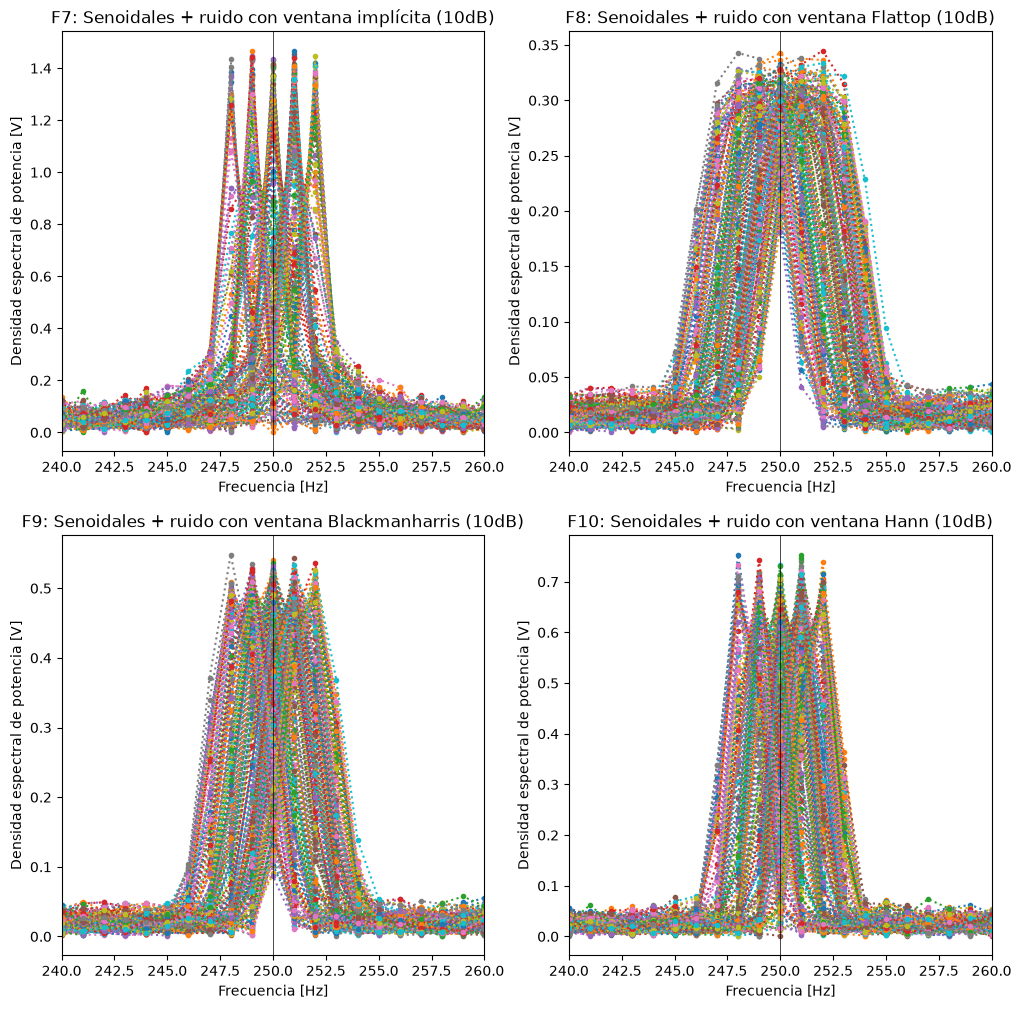

In [17]:
#Rectangular
freq, x_fft_abs = mi_fft(x)
x_fft_abs = 2*x_fft_abs/N
x_fft_abs_traspuesta = np.transpose(x_fft_abs)
plt.figure(7, figsize=(12,12)) 
plt.subplot(2,2,1)
plt.plot(freq,x_fft_abs_traspuesta,":.")
plt.xlim(240,260)
plt.title("F7: Senoidales + ruido con ventana implícita (10dB)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [V]")
plt.axvline(x=250, ymin=0, ymax=1.5, color="black", linewidth=0.5)

a_1_rect = x_fft_abs[:,freq==(omega_cero/(2*np.pi))*N]
indice_maximo = np.argmax(x_fft_abs, axis=1)
omega_rect = freq[indice_maximo]*2*np.pi/fs

#Flattop
flat=win.flattop(N)
x_flat=flat*x

freq, x_fft_abs = mi_fft(x_flat)
x_fft_abs = 2*x_fft_abs/N
x_fft_abs_traspuesta = np.transpose(x_fft_abs)
plt.subplot(2,2,2)
plt.plot(freq,x_fft_abs_traspuesta,":.")
plt.xlim(240,260)
plt.title("F8: Senoidales + ruido con ventana Flattop (10dB)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [V]")
plt.axvline(x=250, ymin=0, ymax=1.5, color="black", linewidth=0.5)

a_1_flat = x_fft_abs[:,freq==(omega_cero/(2*np.pi))*N]
indice_maximo = np.argmax(x_fft_abs, axis=1)
omega_flat = freq[indice_maximo]*2*np.pi/fs

#Blackmanharris
blackh=win.blackmanharris(N)
x_blackh=x*blackh

freq, x_fft_abs = mi_fft(x_blackh)
x_fft_abs_norm = 2*x_fft_abs/N
x_fft_abs_traspuesta = np.transpose(x_fft_abs_norm)
plt.subplot(2,2,3)
plt.plot(freq,x_fft_abs_traspuesta,":.")
plt.xlim(240,260)
plt.title("F9: Senoidales + ruido con ventana Blackmanharris (10dB)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [V]")
plt.axvline(x=250, ymin=0, ymax=1.5, color="black", linewidth=0.5)

a_1_blackh = x_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*N]
indice_maximo = np.argmax(x_fft_abs_norm, axis=1)
omega_blackh = freq[indice_maximo]*2*np.pi/fs

#Hann

freq, x_fft_abs = mi_fft(x_hann)
x_fft_abs_norm = 2*x_fft_abs/N
x_fft_abs_traspuesta = np.transpose(x_fft_abs_norm)
plt.subplot(2,2,4)
plt.plot(freq,x_fft_abs_traspuesta,":.")
plt.xlim(240,260)
plt.title("F10: Senoidales + ruido con ventana Hann (10dB)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [V]")
plt.axvline(x=250, ymin=0, ymax=1.5, color="black", linewidth=0.5)

a_1_hann = x_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*N]
indice_maximo = np.argmax(x_fft_abs_norm, axis=1)
omega_hann = freq[indice_maximo]*2*np.pi/fs

Para simplificación, se realizaron los cuatro gráficos juntos. A pesar del cambio del SNR, no se aprecian cambios significantes. Las señales ventaneadas aparentan tener las mismas cualidades dichas previamente. 

Observando las figuras ahora juntas, la distinción y las similitudes son más notorias. Principalmente, por la manera en que cada una respeta el eje vertical en 250Hz.

#### Histogramas de comparación de estimadores de cada ventana (10dB)

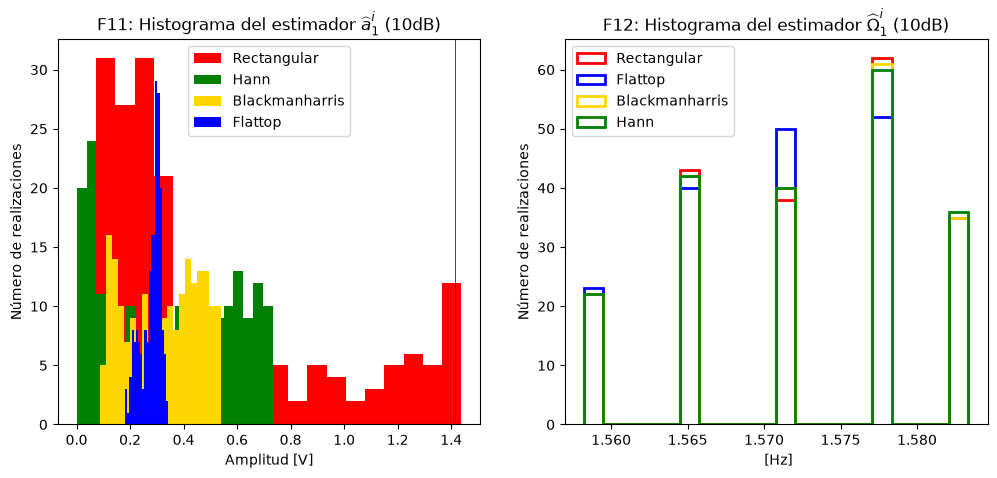

In [18]:
plt.figure(11, figsize=(12, 5))
plt.subplot(1,2,1)
plt.hist(a_1_rect, bins=20, color="red", label="Rectangular")
plt.hist(a_1_hann, bins=20, color="green", label="Hann")
plt.hist(a_1_blackh, bins=20, color="gold", label="Blackmanharris")
plt.hist(a_1_flat, bins=20, color="blue", label="Flattop")
plt.title("F11: Histograma del estimador $\widehat{a}_1^i$ (10dB)")
plt.xlabel("Amplitud [V]")
plt.ylabel("Número de realizaciones")
plt.legend()
plt.axvline(x=np.sqrt(2), ymin=0, ymax=30, color="black", linewidth=0.5)

plt.subplot(1,2,2)
plt.hist(omega_rect, bins=20, color="red", histtype="step", linewidth=2, label="Rectangular")
plt.hist(omega_flat, bins=20, color="blue", histtype="step", linewidth=2, label="Flattop")
plt.hist(omega_blackh, bins=20, color="gold", histtype="step", linewidth=2, label="Blackmanharris")
plt.hist(omega_hann, bins=20, color="green", histtype="step", linewidth=2, label="Hann")
plt.title("F12: Histograma del estimador $\widehat{Ω}_1^i$ (10dB)")
plt.xlabel(" [Hz]")
plt.ylabel("Número de realizaciones")
plt.legend()

Por consiguiente, en cuanto a los histogramas, podemos ver que se repiten los mismos efectos previos. Además, los cambios sutiles que se observan pueden acreditarse a la aleatoriedad del ruido sumado a la sinusoidal.

#### Sesgos y varianzas (10dB)

In [19]:
#Rectangular
esp_a_1 = np.sum(a_1_rect)/200  #Lo mismo que usar np.mean(a_1_rect)
s_a_1_rect=esp_a_1-np.sqrt(2)
var_a_1_rect = np.sum((a_1_rect-esp_a_1)**2)/200

esp_ohm_1 = np.sum(omega_rect)/200 
s_ohm_1_rect=np.mean(esp_ohm_1-omega_uno)
var_ohm_1_rect = np.sum((omega_rect-esp_ohm_1)**2)/200

# Flattop
esp_a_1 = np.sum(a_1_flat)/200  
s_a_1_flat=esp_a_1-np.sqrt(2)
var_a_1_flat = np.sum((a_1_flat-esp_a_1)**2)/200

esp_ohm_1 = np.sum(omega_flat)/200 
s_ohm_1_flat=np.mean(esp_ohm_1-omega_uno)
var_ohm_1_flat = np.sum((omega_flat-esp_ohm_1)**2)/200

#Blackmanharris
esp_a_1 = np.sum(a_1_blackh)/200 
s_a_1_black=esp_a_1-np.sqrt(2)
var_a_1_black = np.sum((a_1_blackh-esp_a_1)**2)/200

esp_ohm_1 = np.sum(omega_blackh)/200 
s_ohm_1_black=np.mean(esp_ohm_1-omega_uno)
var_ohm_1_black = np.sum((omega_blackh-esp_ohm_1)**2)/200

#Hann
esp_a_1 = np.sum(a_1_hann)/200
s_a_1_hann=esp_a_1-np.sqrt(2)
var_a_1_hann = np.sum((a_1_hann-esp_a_1)**2)/200

esp_ohm_1 = np.sum(omega_hann)/200 
s_ohm_1_hann=np.mean(esp_ohm_1-omega_uno)
var_ohm_1_hann = np.sum((omega_hann-esp_ohm_1)**2)/200

In [20]:
df = pd.DataFrame({"Ventana (amplitud)": ["Rectangular", "Hann", "Blackmanharris", "Flattop"], "Sesgo": [s_a_1_rect.round(3), s_a_1_hann.round(3), s_a_1_black.round(3), s_a_1_flat.round(3)], "Varianza": [var_a_1_rect.round(3), var_a_1_hann.round(3),var_a_1_black.round(3),var_a_1_flat.round(3) ]})
df

,Ventana (amplitud),Sesgo,Varianza
0,Rectangular,-0.945,0.181
1,Hann,-1.074,0.056
2,Blackmanharris,-1.091,0.018
3,Flattop,-1.136,0.001


In [21]:
df = pd.DataFrame({"Ventana (frecuencia)": ["Rectangular", "Hann", "Blackmanharris", "Flattop"], "Sesgo": [s_ohm_1_rect.round(5), s_ohm_1_hann.round(5), s_ohm_1_black.round(5), s_ohm_1_flat.round(5)], "Varianza": [var_ohm_1_rect.round(4), var_ohm_1_hann.round(4),var_ohm_1_black.round(4),var_ohm_1_flat.round(4) ]})
df

,Ventana (frecuencia),Sesgo,Varianza
0,Rectangular,0.00014,0.0001
1,Hann,0.00017,0.0001
2,Blackmanharris,0.00014,0.0001
3,Flattop,-0.00014,0.0001


Nuevamente, debido al cambio casi insignificante del SNR, no se observan grandes diferencias entre los cuadros anteriores y estos. La razón, además, por la que es poco probable que coincidan en todos los valores, recae una vez más en la naturaleza del *np.random.normal*.

#### Conclusiones
Principalmente, la variación de las ventanas generó los cambios más significativos en las señales. Tanto en las transformadas de Fourier como los estimadores, especialmente el de amplitud, sufrieron grandes modificaciones. Por otra parte, la alteración del SNR realmente no provocó que se realicen análisis distintos, por lo que el desarrollo de esa segunda parte se simplifcó a compararlo con el previo.

La implementación de la ventana Hann aportó en la perspectiva mencionada, sobre un cambio progresivo entre las cuatro ventanas. Así, se contemplaron cuatro "niveles". Esto no se observó únicamente de manera ilustrativa a través de los gráficos de FFT y los histogramas, sino que también en los cuadros se ve una transición gradual.